In [1]:
import pandas as pd
import re
import json


input_path = "jaemin2_.txt"  

with open(input_path, "r", encoding="utf-8") as f:
    text = f.read()

pattern = r"(\/[^\n]+\/(normal|abnormal)\/[^\n]+)\s*[\s\S]*?(?:```json\s*([\s\S]*?)\s*```|(\{[\s\S]*?\}))"
matches = re.findall(pattern, text, re.DOTALL)

rows = []

for match in matches:
    
    path, truth, json_block, json_raw = match
    json_str = json_block if json_block else json_raw
    
    try:
        data = json.loads(json_str)

        is_scam = bool(data.get("is_scam"))

        if (is_scam and truth == "abnormal") or (not is_scam and truth == "normal"):
            result = True
        else:
            result = False

        rows.append({
            "filename": path.split("/")[-1].strip(),
            "truth": truth,
            "is_scam": data.get("is_scam"),
            "result": result,
            "is_correct": data.get("is_scam"),
            "confidence": data.get("confidence"),
            "risk": data.get("risk"),
            "evidence": "; ".join(data.get("evidence", [])),
            "explanation": data.get("explanation"),            
        })
    except json.JSONDecodeError as e:
        print(f"JSON 파싱 오류 발생 ({path}): {e}")

df = pd.DataFrame(rows, columns=["filename", "truth", "is_scam", "result", "confidence", "risk", "evidence", "explanation"])

output_path = "scam_results.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"CSV 파일 생성 완료: {output_path}")
print(df)


JSON 파싱 오류 발생 (/home/ubuntu/cybercop/video_20251104/normal/0017.mp4): Invalid control character at: line 5 column 90 (char 150)
JSON 파싱 오류 발생 (/home/ubuntu/cybercop/video_20251104/abnormal/0033.mp4): Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
CSV 파일 생성 완료: scam_results.csv
    filename     truth  is_scam  result  confidence  risk  \
0   0011.mp4    normal    False    True        0.35   low   
1   0024.mp4    normal    False    True        0.25   low   
2   0004.mp4    normal    False    True        0.25   low   
3   0001.mp4    normal    False    True        0.15   low   
4   0006.mp4    normal    False    True        0.25   low   
5   0016.mp4    normal    False    True        0.32   low   
6   0005.mp4    normal     True   False        0.92  high   
7   0018.mp4    normal    False    True        0.23   low   
8   0023.mp4    normal    False    True        0.15   low   
9   0007.mp4    normal    False    True        0.35   low   
10  0014.mp4    normal

In [6]:
df.groupby(["truth", "result"]).agg({"filename":"count"})

filename
truth    result          
abnormal False         12
         True          14
normal   False          2
         True          24

In [7]:
df[df['result']==True]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
0,0011.mp4,normal,False,True,0.35,low,알바하게 되면 하는 것; 테이블 정리를 해야 한다,The content discusses common practices for wor...
1,0024.mp4,normal,False,True,0.25,low,innovation in cereal packaging,The video describes a new product for eating c...
2,0004.mp4,normal,False,True,0.25,low,Normal work guidance; Educational advice,The video provides general workplace instructi...
3,0001.mp4,normal,False,True,0.15,low,한 일자 3만시元; 식사도 못하고 졸도 못,The video discusses working conditions and pot...
4,0006.mp4,normal,False,True,0.25,low,50대; CuPage,The video features a person in a car discussin...
5,0016.mp4,normal,False,True,0.32,low,고정한 장면; 인물의 동작,The description includes normal activities lik...
7,0018.mp4,normal,False,True,0.23,low,Korean text,The description contains typical Korean phrase...
8,0023.mp4,normal,False,True,0.15,low,nonstick coating; multi-cooker pan,The video promotes a nonstick cooking pan and ...
9,0007.mp4,normal,False,True,0.35,low,7일간 단기알바 만으로 100만원 벌기,The description indicates a job challenge with...
10,0014.mp4,normal,False,True,0.25,low,peated with milk; stirring mixed drink,The video shows a standard beverage preparatio...


In [8]:
df[df['result']==False]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
6,0005.mp4,normal,True,False,0.92,high,requests for deposit; direct ask to pay,The description mentions a request for an addi...
21,0026.mp4,normal,True,False,0.90,high,우배 택시互联,The video contains promotional content with ex...
26,0025.mp4,abnormal,False,False,0.35,low,benami recommending code; purchase gold; recom...,The video discusses purchasing features and of...
30,0004.mp4,abnormal,False,False,0.25,low,"Requests for passwords, OTPs, account/ID numbe...",The video description mentions a request to lo...
33,0006.mp4,abnormal,False,False,0.35,low,하루에 50만 원씩 받어요; 디지털 화페의 고가 매입,The video does not contain explicit indicators...
35,0005.mp4,abnormal,False,False,0.35,low,揭示了关于汽车价格的陷阱,The video seems to provide information about p...
36,0018.mp4,abnormal,False,False,0.23,low,다들 뭐해; 업전체,The conversation appears to be a casual chat a...
37,0007.mp4,abnormal,False,False,0.15,low,사람들에게 공과 허망을 불어 놓아주는 사이비 교수,The video shows a martial arts demonstration w...
39,0031.mp4,abnormal,False,False,0.35,low,"10,000",The description includes a numeric value of '1...
40,0012.mp4,abnormal,False,False,0.25,low,normal patterns without inducement,The video description does not contain explici...


AP (mAP): 0.8140


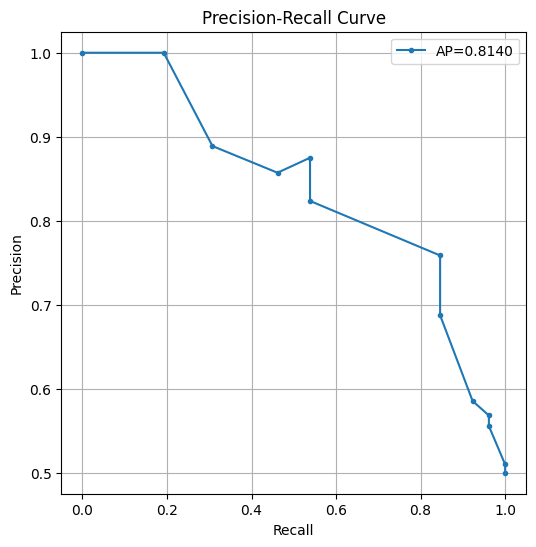

Optimal threshold (F1 max): 0.35


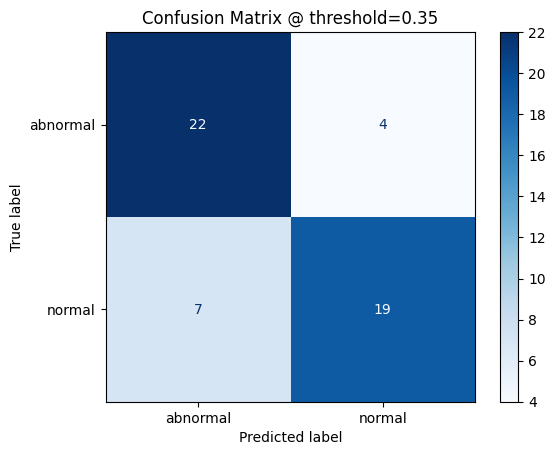

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

# abnormal = positive class
df['y_true'] = df['truth'].apply(lambda x: 1 if x=='abnormal' else 0)
y_true = df['y_true'].values
y_scores = df['confidence'].values

# Precision-Recall + AP
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"AP (mAP): {ap:.4f}")

# PR curve 시각화
plt.figure(figsize=(6,6))
plt.plot(recall, precision, marker='.', label=f'AP={ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# 최적 threshold 선택 (F1 최대)
f1_scores = 2*precision*recall/(precision+recall+1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (F1 max): {best_threshold:.2f}")

# Confusion matrix
y_pred = (y_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(cm, display_labels=['abnormal', 'normal'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={best_threshold:.2f}')
plt.show()
